In [1]:
import scipy as sp
import numpy as np
import os
import matplotlib.pyplot as plt
import sympy as sp
from sympy.abc import x, y

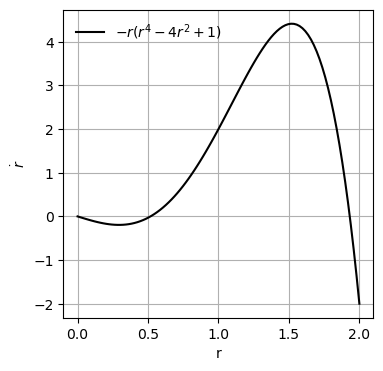

In [16]:
r = np.linspace(0, 2.0, 100)
rdot = lambda r: -r**5 + 4*r**3 - r

fig, ax = plt.subplots(1,1, figsize = (4,4))
ax.plot(r, rdot(r), color = 'k', label = r'$-r(r^4 - 4r^2 + 1)$')
ax.set_xlabel("r")
ax.grid(True)
ax.set_ylabel(r"$\dot{r}$")
ax.legend(frameon = False)
plt.savefig("plot.pdf")

In [50]:
from sympy.abc import x, y

sp.solveset(sp.cos(y)*(x**2 - 1)**2 + 2*sp.sin(y), x, domain = sp.S.Complexes)

{-sqrt(-sqrt(-sin(2*y))/cos(y) + 1), sqrt(-sqrt(-sin(2*y))/cos(y) + 1), -sqrt(sqrt(-sin(2*y))/cos(y) + 1), sqrt(sqrt(-sin(2*y))/cos(y) + 1)}

In [56]:
from sympy.abc import x, y

equations = [-2*y - x*((x*x + y*y)**2 - 4*(x*x + y*y) + 1),
            2*x - y*((x*x + y*y)**2 - 4*(x*x + y*x) + 1)] 

Jacobi = sp.Matrix(equations).jacobian([x, y])
print(Jacobi.subs({x: 0, y: 0}))
eigenvalues = Jacobi.subs({x: 0, y: 0}).eigenvals()
print("Eigenvalues of Jacobi:", eigenvalues)

sp.solve(equations, [x, y], domain = sp.S.Complexes)

Matrix([[-1, -2], [2, -1]])
Eigenvalues of Jacobi: {-1 - 2*I: 1, -1 + 2*I: 1}


[(0, 0)]

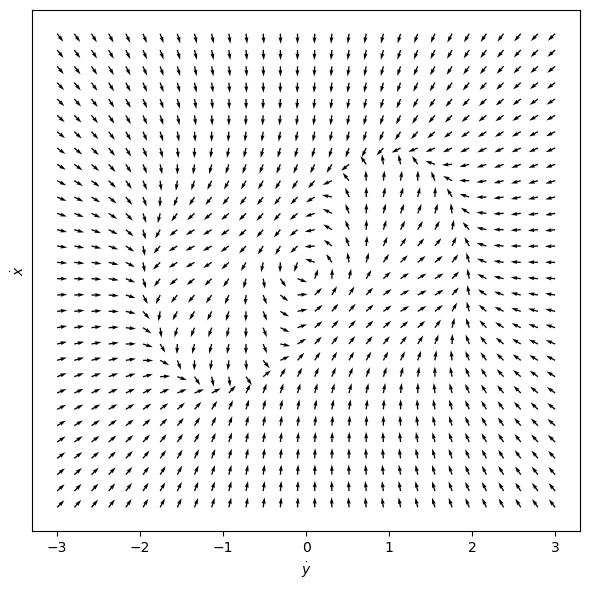

In [ ]:
def eq(x, y):

    U = -2*y - x*((x*x + y*y)**2 - 4*(x*x + y*y) + 1)
    V = 2*x - y*((x*x + y*y)**2 - 4*(x*x + y*x) + 1)

    return U, V

funcs = [eq]
v = np.linspace(-3, 3, 30)
x = np.linspace(-3, 3, 30)

v, x = np.meshgrid(v, x)

fig, ax = plt.subplots(1,1, figsize = (6, 6))
for i, fun in enumerate(funcs):

    U, V = fun(v, x)
    norm = 1/np.sqrt(U**2 + V**2)
    ax.quiver(v, x, norm*U, norm*V)

ax.set_ylabel(r"$\dot{x}$")
ax.set_xlabel(r"$\dot{y}$")
ax.set_yticks([])
ax.set_yticks([])
fig.tight_layout()
plt.savefig("0.pdf")
plt.show()

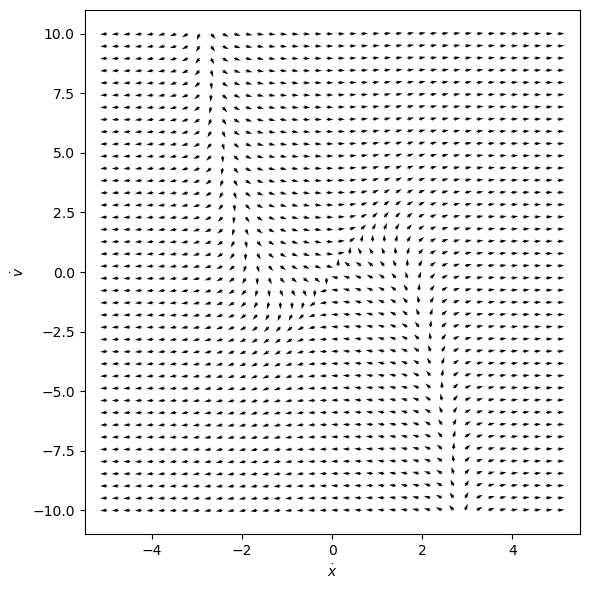

In [35]:
def eq(v, x):

    V = 2*((1/3)*v**2 - 1)*v + x
    X = v

    return V, X

funcs = [eq]
x = np.linspace(-5, 5, 40)
y = np.linspace(-10, 10, 40)

x, y = np.meshgrid(x, y)

fig, ax = plt.subplots(1,1, figsize = (6, 6))
for i, fun in enumerate(funcs):

    U, V = fun(x, y)
    norm = 1/np.sqrt(U**2 + V**2)
    ax.quiver(x, y, norm*U, norm*V)

ax.set_ylabel(r"$\dot{v}$")
ax.set_xlabel(r"$\dot{x}$")
fig.tight_layout()
plt.savefig("phase0.pdf")
plt.show()

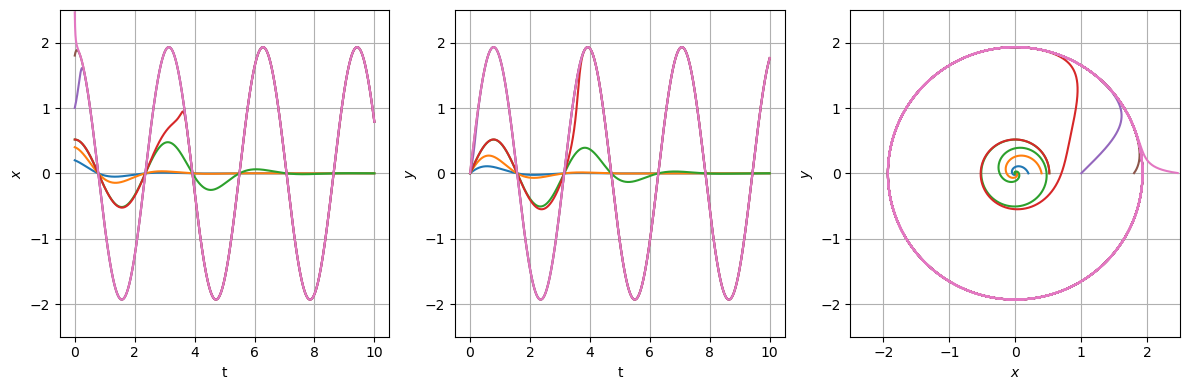

In [48]:
fig, ax = plt.subplots(1,3, figsize = (12, 4))

omegas = [10.0*(0.5 + i*0.5) for i in range(6)]

for i in range(7):
    data = np.loadtxt(f"lab_{i}.dat").T

    ax[0].plot(data[0], data[1])
    ax[0].set_xlabel("t")
    ax[0].set_ylabel(r"$x$")
    ax[0].grid(True)

    ax[1].set_xlabel("t")
    ax[1].plot(data[0], data[2]) 
    ax[1].set_ylabel(r"$y$")
    ax[1].grid(True)

    ax[2].plot(data[1], data[2])
    ax[2].set_xlabel(r"$x$")
    ax[2].set_ylabel(r"$y$")
    ax[2].grid(True)

omega_lim = 2.5
theta_lim = 2.5

ax[0].set_ylim(-theta_lim, theta_lim)
ax[1].set_ylim(-omega_lim, omega_lim)
ax[2].set_xlim(-omega_lim, omega_lim)
ax[2].set_ylim(-theta_lim, theta_lim)

    #ax[i, 2].axis('equal')

fig.tight_layout()
plt.savefig("3.pdf")
plt.show()

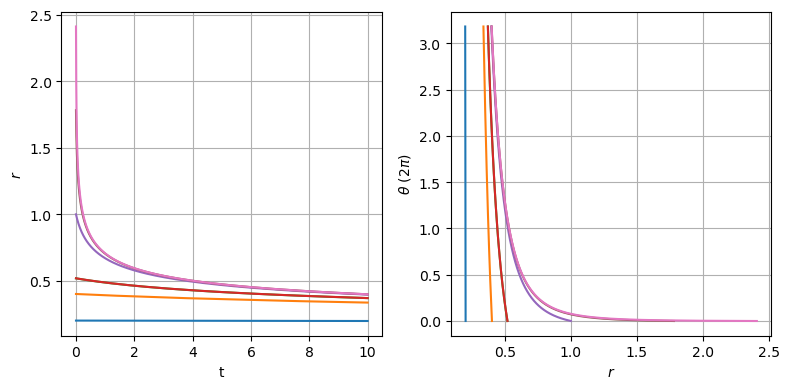

In [28]:
fig, ax = plt.subplots(1,2, figsize = (8, 4))

theta = lambda t, c: (2*t + c)


for i in range(7):
    data = np.loadtxt(f"lab_{i}.dat").T
    t = data[0]
    r = data[1]
    th = theta(t, 0)

    ax[0].plot(t, r)
    ax[0].set_xlabel("t")
    ax[0].set_ylabel(r"$r$")
    ax[0].grid(True)

    ax[1].plot(r, th/2/np.pi)
    ax[1].set_xlabel(r"$r$")
    ax[1].set_ylabel(r"$\theta$ $(2\pi)$")
    ax[1].grid(True)

omega_lim = 2.5
theta_lim = 2.5

#ax[0].set_ylim(-theta_lim, theta_lim)
#ax[1].set_ylim(-omega_lim, omega_lim)

    #ax[i, 2].axis('equal')

fig.tight_layout()
plt.savefig("34.pdf")
plt.show()

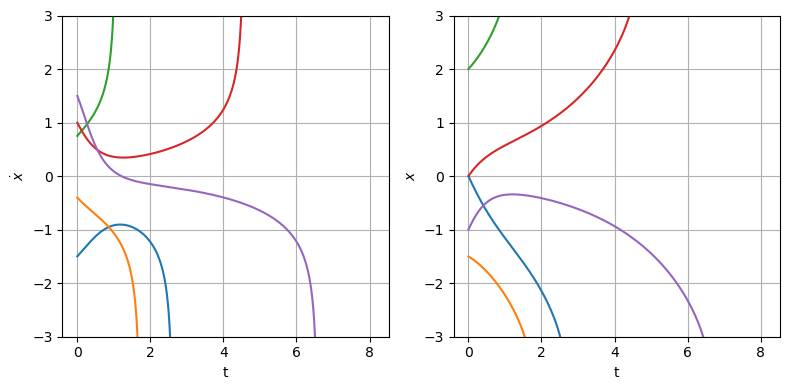

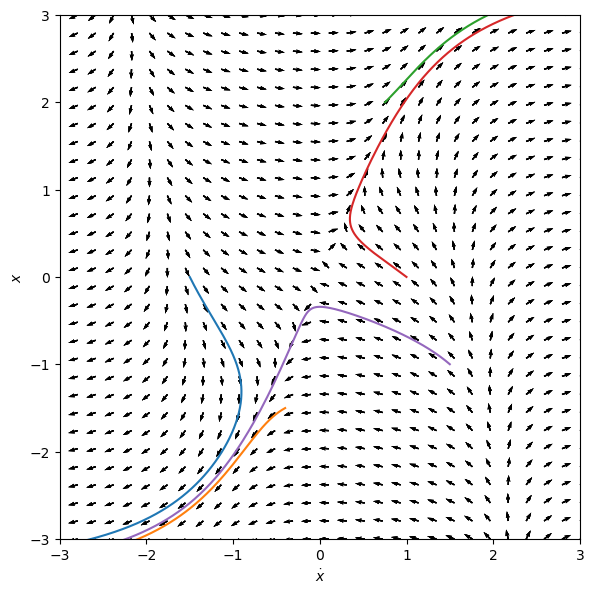

In [61]:
def eq(v, x):

    V = 2*((1/3)*v**2 - 1)*v + x
    X = v

    return V, X

funcs = [eq]
x = np.linspace(-3, 3, 30)
y = np.linspace(-3, 3, 30)

x, y = np.meshgrid(x, y)

U, V = fun(x, y)
norm = 1/np.sqrt(U**2 + V**2)

fig, ax = plt.subplots(1,2, figsize = (8, 4))
omega_lim = 3
theta_lim = 3
ax[0].set_ylim(-theta_lim, theta_lim)
ax[1].set_ylim(-omega_lim, omega_lim)
for i in range(5):
    data = np.loadtxt(f"lab_{i}.dat").T

    ax[0].plot(data[0], data[1])
    ax[0].set_xlabel("t")
    ax[0].set_ylabel(r"$\dot{x}$")
    ax[0].grid(True)

    ax[1].set_xlabel("t")
    ax[1].plot(data[0], data[2]) 
    ax[1].set_ylabel(r"$x$")
    ax[1].grid(True)

fig.tight_layout()
plt.savefig("6.pdf")

fig2, ax2 = plt.subplots(1,1,figsize = (6,6))
for i in range(5):
    data = np.loadtxt(f"lab_{i}.dat").T

    ax2.plot(data[1], data[2])
    ax2.set_xlabel(r"$\dot{x}$")
    ax2.set_ylabel(r"$x$")
    ax2.quiver(x, y, norm*U, norm*V)
fig2.tight_layout()
ax2.set_xlim(-3,3)
ax2.set_ylim(-3,3)


fig.tight_layout()
plt.savefig("7.pdf")
plt.show()